# Chapter 11 — Neural networks that understand language

> *Grokking Deep Learning* — Andrew W. Trask

Chapter ini berpindah dari image data menuju **Natural Language Processing (NLP)**. Fokus utamanya adalah bagaimana text diubah menjadi angka, bagaimana **word embeddings** dipelajari, bagaimana pilihan target/loss memengaruhi informasi yang tersimpan dalam embedding, dan bagaimana muncul fenomena **word analogies**.

## Learning Objectives

Setelah menyelesaikan chapter ini, kita diharapkan dapat:

1. Menjelaskan apa yang dimaksud dengan **NLP**.
2. Memahami mengapa raw text perlu dikonversi menjadi representasi numerik.
3. Menjelaskan **one-hot encoding** untuk merepresentasikan vocabulary.
4. Memahami **bag of words** dan keterbatasannya.
5. Menjelaskan bagaimana `weights_0_1` dapat diperlakukan sebagai **embedding layer**.
6. Memahami hubungan antara target prediction dan makna yang dipelajari oleh neuron.
7. Menjelaskan mengapa **loss function** menentukan pola yang dipelajari network.
8. Memahami konsep **filling in the blank**, negative sampling, dan word analogy.

## Chapter Roadmap

**Raw text → Numerical representation → Supervised NLP → IMDB sentiment → One-hot / bag of words → Embedding layer → Word similarity → Filling in the blank → Loss function → Word analogies**

Chapter 11 menggunakan dua jenis target yang berbeda untuk menunjukkan bahwa network dapat mempelajari representasi kata yang berbeda meskipun dataset dan arsitekturnya sangat mirip.

## What Does It Mean to Understand Language?

Pada chapter sebelumnya, input neural network berupa angka dari image. Sekarang inputnya berupa **text**.

Buku memulai dengan pertanyaan: prediksi apa yang dapat dilakukan terhadap language?

Contohnya:
- menentukan batas antar kata;
- menentukan batas antar kalimat;
- memprediksi part of speech;
- menemukan phrase;
- mengenali named entity;
- menentukan referensi pronoun;
- memprediksi sentiment.

Secara umum, NLP dalam pembahasan buku dapat dilihat sebagai tugas untuk **memberi label text, menghubungkan bagian text, atau mengisi informasi yang hilang berdasarkan context**.

In [1]:
# Contoh sederhana kategori tugas NLP yang dibahas di chapter.
tasks = {
    "Label text": 3,
    "Link text": 1,
    "Fill missing information": 1
}

print(tasks)

{'Label text': 3, 'Link text': 1, 'Fill missing information': 1}


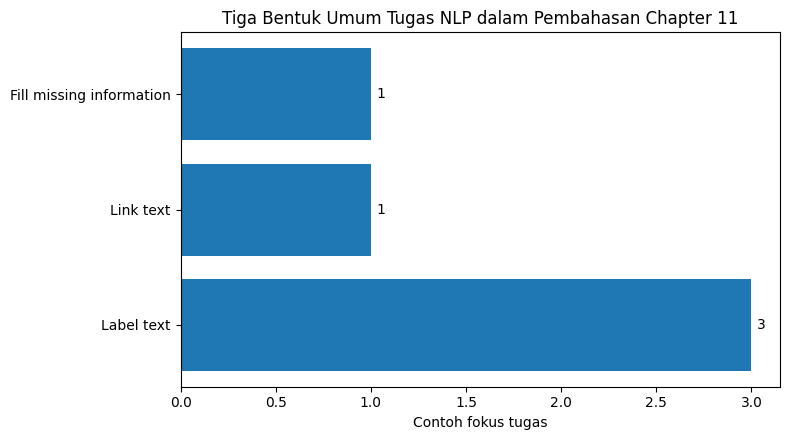

In [2]:
import matplotlib.pyplot as plt

labels = list(tasks.keys())
values = list(tasks.values())

plt.figure(figsize=(8, 4.5))
bars = plt.barh(labels, values)
plt.xlabel("Contoh fokus tugas")
plt.title("Tiga Bentuk Umum Tugas NLP dalam Pembahasan Chapter 11")
for b, v in zip(bars, values):
    plt.text(v + 0.03, b.get_y() + b.get_height()/2, str(v), va="center")
plt.tight_layout()
plt.show()

Angka pada chart hanya menghitung contoh yang diringkas dari uraian buku, bukan statistik tentang seluruh bidang NLP. Tujuannya menunjukkan tiga bentuk masalah yang menjadi kerangka awal chapter.

## Supervised NLP

Prinsip **supervised learning** tetap sama:

**What you know → prediction → What you want to know**

Perbedaannya adalah `what you know` sekarang berupa raw text. Karena neural network bekerja dengan angka, text harus dikonversi menjadi matrix atau vector numerik.

Buku menekankan bahwa cara melakukan konversi ini sangat penting karena neural network mencari **correlation antara input dan output**.

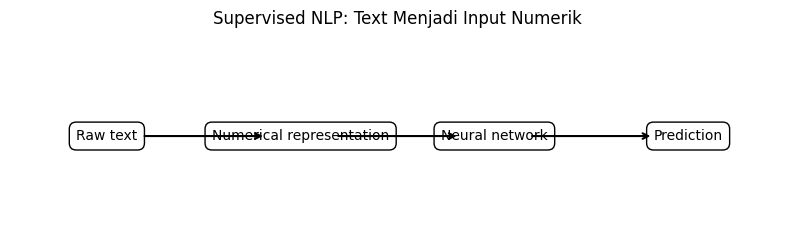

In [3]:
# Alur representasi data dalam supervised NLP.
stages = ["Raw text", "Numerical representation", "Neural network", "Prediction"]
x = range(len(stages))

plt.figure(figsize=(10, 2.7))
for i, stage in enumerate(stages):
    plt.text(i, 0.5, stage, ha="center", va="center",
             bbox=dict(boxstyle="round,pad=0.5", fill=False))
    if i < len(stages)-1:
        plt.annotate("", xy=(i+0.82, 0.5), xytext=(i+0.18, 0.5),
                     arrowprops=dict(arrowstyle="->", lw=1.5))
plt.xlim(-0.5, len(stages)-0.5)
plt.ylim(0, 1)
plt.axis("off")
plt.title("Supervised NLP: Text Menjadi Input Numerik")
plt.show()

## IMDB Movie Reviews Dataset

Contoh utama supervised NLP pada chapter adalah **IMDB movie reviews dataset**.

Strukturnya berupa pasangan:

**review → rating**

Tujuan awalnya adalah memprediksi apakah review bersifat **positive** atau **negative**.

Buku menggunakan contoh seperti review yang mengandung kata-kata negatif, lalu menunjukkan bahwa kata tertentu dapat memiliki correlation dengan sentiment.

In [4]:
# Contoh ilustratif struktur dataset review -> label.
reviews = [
    "this movie was terrible",
    "this movie was fantastic",
    "the story was boring",
    "the acting was brilliant"
]
labels = ["negative", "positive", "negative", "positive"]

for review, label in zip(reviews, labels):
    print(f"{label:>8} | {review}")

negative | this movie was terrible
positive | this movie was fantastic
negative | the story was boring
positive | the acting was brilliant


## Capturing Word Correlation: Bag of Words

Buku kemudian memperkenalkan **bag of words**.

Jika vocabulary berisi `N` kata, setiap review direpresentasikan sebagai vector berdimensi `N`. Setiap kolom mewakili sebuah kata.

Untuk versi paling sederhana:
- `1` berarti kata muncul;
- `0` berarti kata tidak muncul.

Representasi ini disebut **one-hot encoding** ketika setiap kata individual direpresentasikan sebagai vector dengan satu posisi aktif.

In [5]:
import numpy as np

# Contoh one-hot encoding persis dengan struktur contoh buku.
onehots = {}
onehots["cat"] = np.array([1,0,0,0])
onehots["the"] = np.array([0,1,0,0])
onehots["dog"] = np.array([0,0,1,0])
onehots["sat"] = np.array([0,0,0,1])

sentence = ["the", "cat", "sat"]
x = onehots[sentence[0]] + onehots[sentence[1]] + onehots[sentence[2]]

print("Vocabulary order: cat, the, dog, sat")
print("Sentence:", " ".join(sentence))
print("Sent Encoding:", x)

Vocabulary order: cat, the, dog, sat
Sentence: the cat sat
Sent Encoding: [1 1 0 1]


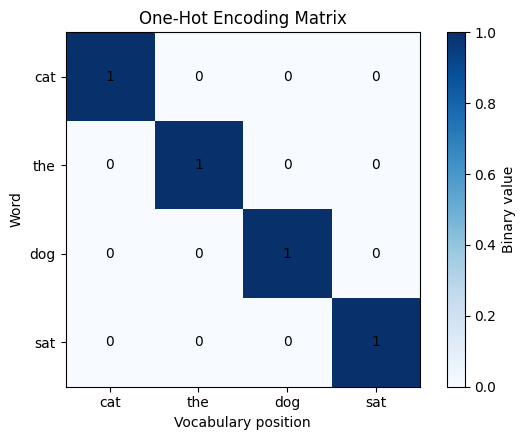

In [6]:
matrix = np.vstack([onehots[w] for w in ["cat","the","dog","sat"]])

plt.figure(figsize=(6, 4.5))
plt.imshow(matrix, cmap="Blues", vmin=0, vmax=1)
plt.xticks(range(4), ["cat","the","dog","sat"])
plt.yticks(range(4), ["cat","the","dog","sat"])
plt.xlabel("Vocabulary position")
plt.ylabel("Word")
plt.title("One-Hot Encoding Matrix")
for r in range(4):
    for c in range(4):
        plt.text(c, r, str(matrix[r,c]), ha="center", va="center")
plt.colorbar(label="Binary value")
plt.tight_layout()
plt.show()

### Dari Word ke Sentence Encoding

Dengan menjumlahkan vector:

`the + cat + sat`

diperoleh:

`[1, 1, 0, 1]`

Artinya vocabulary yang aktif adalah `cat`, `the`, dan `sat`.

Buku juga mencatat bahwa ketika kata yang sama muncul beberapa kali, kita dapat menjumlahkan kemunculannya atau menggunakan unique occurrence. Dalam contoh chapter, pendekatan unique occurrence biasanya bekerja lebih baik untuk language.

## Predicting Movie Reviews

Setelah text diubah menjadi numerical representation, vector tersebut dapat digunakan sebagai input neural network.

Arsitektur dasarnya mengikuti pola yang sudah dipelajari:

**input → weights_0_1 → hidden layer → weights_1_2 → prediction**

Tujuannya adalah memprediksi label sentiment `positive` atau `negative`.

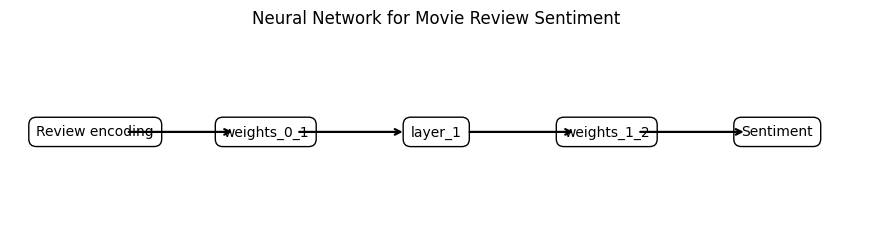

In [7]:
# Bentuk arsitektur sentiment network secara konseptual.
nodes = ["Review encoding", "weights_0_1", "layer_1", "weights_1_2", "Sentiment"]

plt.figure(figsize=(11, 2.6))
for i, node in enumerate(nodes):
    plt.text(i, 0.5, node, ha="center", va="center",
             bbox=dict(boxstyle="round,pad=0.55", fill=False))
    if i < len(nodes)-1:
        plt.annotate("", xy=(i+0.82,0.5), xytext=(i+0.18,0.5),
                     arrowprops=dict(arrowstyle="->", lw=1.6))
plt.xlim(-0.5, len(nodes)-0.5)
plt.ylim(0,1)
plt.axis("off")
plt.title("Neural Network for Movie Review Sentiment")
plt.show()

## Intro to an Embedding Layer

Buku kemudian memperkenalkan shortcut penting.

Jika input adalah vector 1 dan 0, operasi vector-matrix multiplication sebenarnya banyak melakukan perkalian dengan `0`. Secara matematis, hasilnya sama dengan:

1. memilih row `weights_0_1` yang sesuai dengan kata yang muncul;
2. menjumlahkan row tersebut.

Karena itu `weights_0_1` dapat diperlakukan sebagai **embedding layer**.

Ini bukan perubahan matematis pada hasil `layer_1`; yang berubah terutama adalah **cara komputasinya** agar lebih efisien.

In [8]:
# Demonstrasi ekuivalensi one-hot × matrix dengan row selection.
np.random.seed(1)
weights_demo = np.random.randn(4, 3)

sentence_vector = np.array([1, 1, 0, 1])
one_hot_result = sentence_vector.dot(weights_demo)

selected_rows_sum = (
    weights_demo[0] +
    weights_demo[1] +
    weights_demo[3]
)

print("One-hot × weights:")
print(one_hot_result)
print("\nSelected rows summed:")
print(selected_rows_sum)
print("\nEquivalent:", np.allclose(one_hot_result, selected_rows_sum))

One-hot × weights:
[ 0.30200637  1.71575915 -4.88985116]

Selected rows summed:
[ 0.30200637  1.71575915 -4.88985116]

Equivalent: True


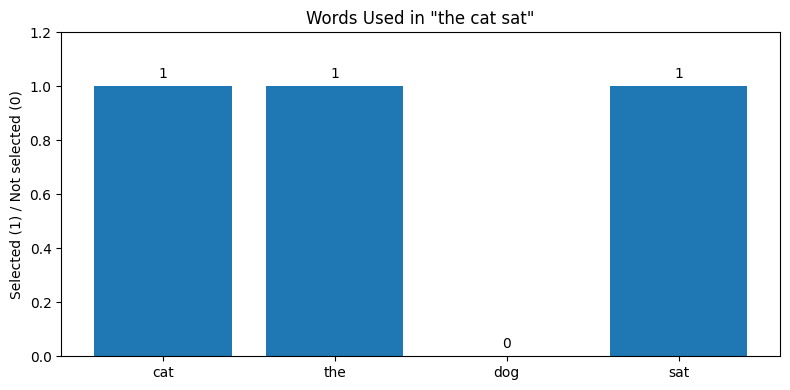

In [9]:
# Visualisasi row yang dipilih oleh sentence "the cat sat".
words = ["cat", "the", "dog", "sat"]
active = sentence_vector

plt.figure(figsize=(8, 4))
bars = plt.bar(words, active)
plt.ylim(0, 1.2)
plt.ylabel("Selected (1) / Not selected (0)")
plt.title('Words Used in "the cat sat"')
for b, v in zip(bars, active):
    plt.text(b.get_x()+b.get_width()/2, v+0.03, str(v), ha="center")
plt.tight_layout()
plt.show()

### Mengapa Embedding Lebih Efisien?

Buku menjelaskan bahwa vocabulary sentiment berada pada orde **70,000 words**. Dalam vector yang sangat besar tersebut, sebagian besar elemen adalah `0`.

Embedding layer menghindari pekerjaan yang tidak perlu dengan langsung mengambil row yang relevan dari `weights_0_1`.

Jadi, konsepnya:

**One-hot vector → banyak operasi dengan 0**

vs.

**Embedding → pilih row yang diperlukan → sum/average**

## Source Configuration: Sentiment Embedding Network

Konfigurasi source yang diperkenalkan pada chapter:

- `alpha = 0.01`
- `iterations = 2`
- `hidden_size = 100`
- `weights_0_1.shape = (len(vocab), 100)`
- `weights_1_2.shape = (100, 1)`
- training menggunakan review awal dan menyisakan **1000 review terakhir untuk testing**.

Source melaporkan:
- Iteration 0 training accuracy: **0.832**
- Iteration 1 training accuracy: **0.866333...**
- Test Accuracy: **0.849**

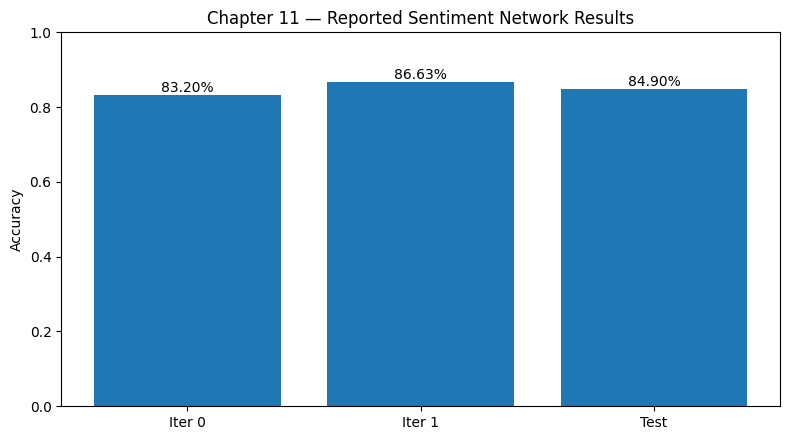

In [10]:
# Source-reported results from Chapter 11.
iterations = ["Iter 0", "Iter 1", "Test"]
accuracy = [0.832, 0.8663333333333333, 0.849]

plt.figure(figsize=(8, 4.5))
bars = plt.bar(iterations, accuracy)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Chapter 11 — Reported Sentiment Network Results")
for b, v in zip(bars, accuracy):
    plt.text(b.get_x()+b.get_width()/2, v, f"{v:.2%}",
             ha="center", va="bottom")
plt.tight_layout()
plt.show()

**Interpretasi:** hasil tersebut adalah angka yang tercetak pada source chapter, bukan hasil run ulang pada notebook ini. Test Accuracy yang dilaporkan adalah **84.9%**.

## Interpreting the Output: Word Similarity

Setelah network dilatih untuk sentiment, kita dapat melihat kata-kata yang memiliki representasi embedding yang mirip.

Buku menggunakan **Euclidean distance** untuk membandingkan row pada `weights_0_1`.

Karena source menyimpan score sebagai `-distance`, nilai yang lebih dekat ke `0` berarti kata lebih dekat dengan target.

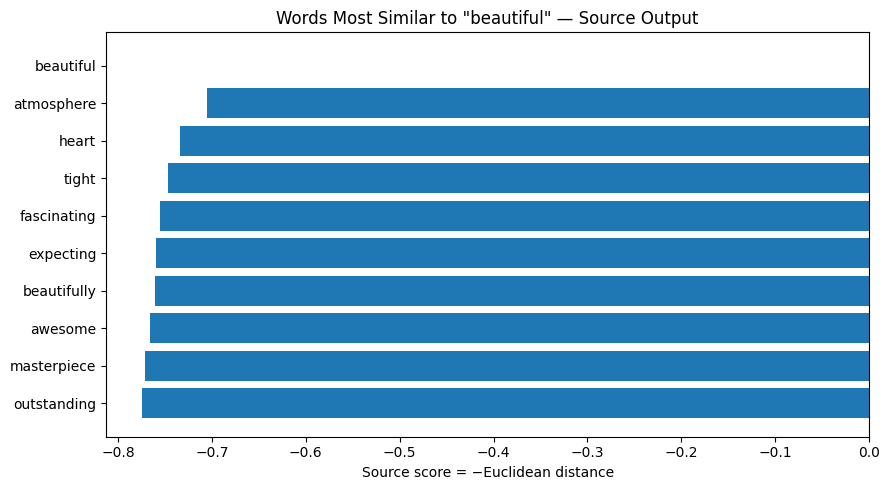

In [11]:
# Source-reported similarity results for "beautiful".
beautiful_words = [
    "beautiful", "atmosphere", "heart", "tight", "fascinating",
    "expecting", "beautifully", "awesome", "masterpiece", "outstanding"
]
beautiful_scores = [
    -0.0, -0.70542101298, -0.7339429768542354, -0.7470388145765346,
    -0.7549291974, -0.759886970744, -0.7603669338,
    -0.76647368382398, -0.7708280057, -0.7740642167
]

plt.figure(figsize=(9, 5))
plt.barh(beautiful_words[::-1], beautiful_scores[::-1])
plt.xlabel("Source score = −Euclidean distance")
plt.title('Words Most Similar to "beautiful" — Source Output')
plt.tight_layout()
plt.show()

Hasil ini menunjukkan sesuatu yang penting: network tidak otomatis memahami “makna kata” seperti manusia. Untuk tugas sentiment, kata-kata dikelompokkan berdasarkan **kegunaannya dalam memprediksi label positive/negative**.

Buku bahkan menyoroti bahwa `beautiful` dan `atmosphere` dapat menjadi sangat dekat dalam embedding sentiment meskipun secara linguistik keduanya memiliki fungsi yang berbeda.

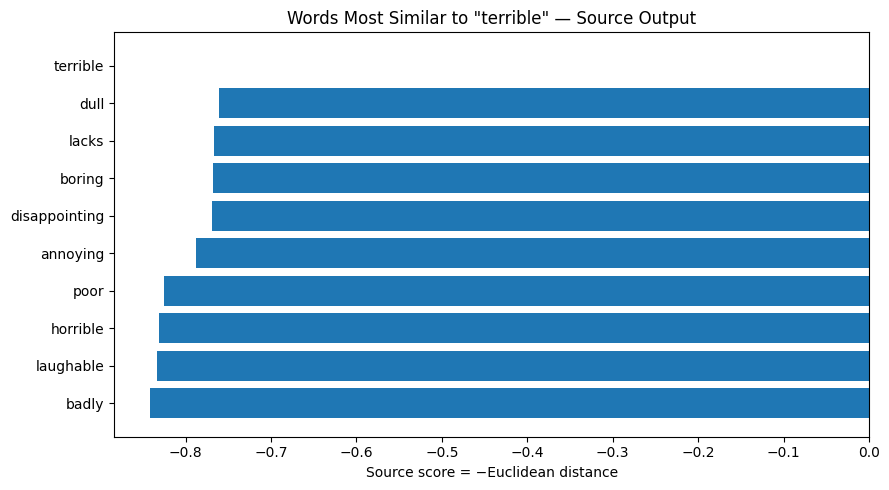

In [12]:
# Source-reported similarity results for "terrible".
terrible_words = [
    "terrible", "dull", "lacks", "boring", "disappointing",
    "annoying", "poor", "horrible", "laughable", "badly"
]
terrible_scores = [
    -0.0, -0.760788602671491, -0.76706470275372, -0.7682894961694,
    -0.768657, -0.78786389931, -0.825784172378292,
    -0.83154121717, -0.8340279599, -0.84165373783678
]

plt.figure(figsize=(9, 5))
plt.barh(terrible_words[::-1], terrible_scores[::-1])
plt.xlabel("Source score = −Euclidean distance")
plt.title('Words Most Similar to "terrible" — Source Output')
plt.tight_layout()
plt.show()

## What Is the Meaning of a Neuron?

Pesan penting chapter:

**Meaning is entirely based on the target labels being predicted.**

Jika target hanya `positive` atau `negative`, embedding akan cenderung mengorganisasi kata berdasarkan usefulness terhadap sentiment tersebut.

Dengan kata lain, embedding bukan “kamus makna universal”. Representasi yang dipelajari sangat dipengaruhi oleh **apa yang network diminta untuk prediksi**.

## Filling in the Blank

Untuk memperoleh representasi kata yang lebih nuanced, buku mengganti target sentiment menjadi tugas **fill-in-the-blank**.

Contoh:

> *Mary had a little lamb whose __________ was white as snow.*

Network tidak lagi diminta menjawab “positive atau negative”, tetapi mencoba menebak kata yang hilang berdasarkan context.

Buku menggunakan:
- phrase berisi lima kata;
- satu **focus term** dihilangkan;
- network memprediksi identity kata yang hilang;
- **negative sampling** digunakan agar tidak perlu memprediksi seluruh vocabulary setiap kali.

In [13]:
# Contoh struktur task fill-in-the-blank.
sentence = ["mary", "had", "a", "little", "lamb"]
focus_index = 4

context = sentence[:focus_index] + sentence[focus_index+1:]
focus_word = sentence[focus_index]

print("Context:", context)
print("Focus term:", focus_word)

Context: ['mary', 'had', 'a', 'little']
Focus term: lamb


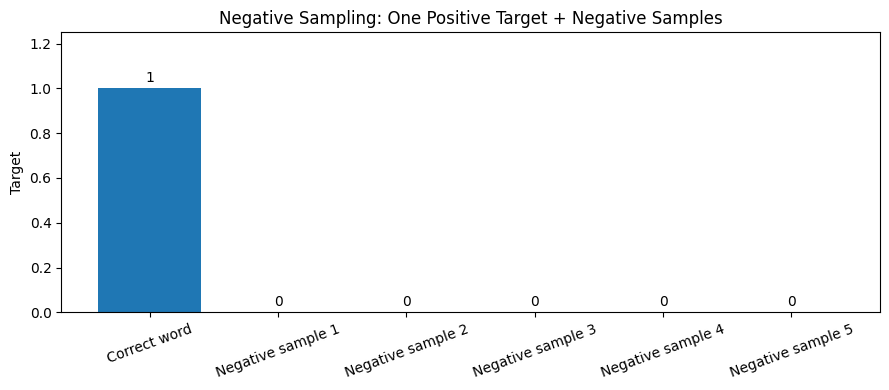

In [14]:
# Ilustrasi negative sampling.
labels = ["Correct word", "Negative sample 1", "Negative sample 2",
          "Negative sample 3", "Negative sample 4", "Negative sample 5"]
target = [1, 0, 0, 0, 0, 0]

plt.figure(figsize=(9, 4))
bars = plt.bar(labels, target)
plt.ylim(0, 1.25)
plt.ylabel("Target")
plt.title("Negative Sampling: One Positive Target + Negative Samples")
for b, v in zip(bars, target):
    plt.text(b.get_x()+b.get_width()/2, v+0.03, str(v), ha="center")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Visual di atas menunjukkan struktur target yang digunakan source: `layer_2_target` memiliki `negative + 1` posisi dan posisi pertama diberi nilai `1`. Nilai lain menjadi `0`.

Tujuan negative sampling adalah menghindari biaya memprediksi ribuan vocabulary labels pada setiap forward propagation.

## Meaning Is Derived from Loss

Chapter 11 kemudian membawa pembahasan ke insight yang lebih fundamental:

> **Neural networks don't really learn data; they minimize the loss function.**

Dua network dapat memiliki:
- starting weights yang sama;
- dataset yang sama;
- arsitektur yang mirip;

tetapi belajar representasi yang berbeda jika **target atau loss function** berbeda.

Pada chapter ini:
- target sentiment → embedding mengelompokkan kata berdasarkan usefulness untuk sentiment;
- target fill-in-the-blank → embedding memperoleh signal yang lebih kaya mengenai hubungan antar kata.

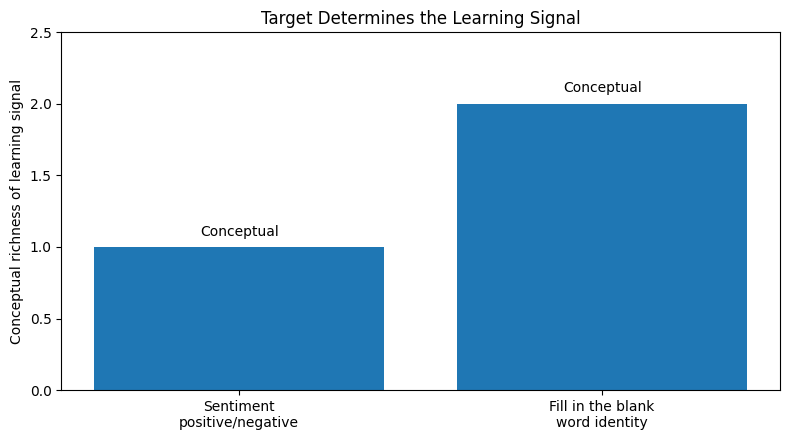

In [15]:
# Konsep: target berbeda memberikan signal yang berbeda.
targets = ["Sentiment\npositive/negative", "Fill in the blank\nword identity"]
signal_richness = [1, 2]  # skala konseptual, bukan hasil eksperimen

plt.figure(figsize=(8, 4.5))
bars = plt.bar(targets, signal_richness)
plt.ylabel("Conceptual richness of learning signal")
plt.title("Target Determines the Learning Signal")
plt.ylim(0, 2.5)
plt.text(0, 1.08, "Conceptual", ha="center")
plt.text(1, 2.08, "Conceptual", ha="center")
plt.tight_layout()
plt.show()

**Penting:** tinggi bar pada chart ini bukan angka eksperimen dari buku. Ini hanya visual konseptual untuk membedakan bahwa fill-in-the-blank memberikan target yang lebih nuanced dibanding binary sentiment.

## Comparing the Two Embedding Spaces

Source memperlihatkan dua output untuk kata `terrible`.

**Sentiment network:**
`terrible → dull, lacks, boring, disappointing, ...`

**Fill-in-the-blank network:**
`terrible → horrible, brilliant, pathetic, phenomenal, ...`

Perbedaannya menunjukkan bahwa kata-kata dapat dikelompokkan dengan cara berbeda ketika **target prediction** berubah.

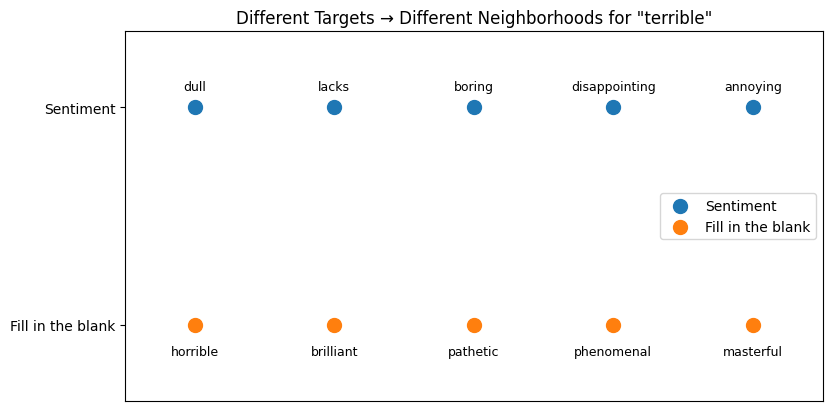

In [16]:
# Source-reported top neighbors for "terrible".
sentiment_neighbors = ["dull", "lacks", "boring", "disappointing", "annoying"]
fill_blank_neighbors = ["horrible", "brilliant", "pathetic", "phenomenal", "masterful"]

positions = np.arange(5)

plt.figure(figsize=(9, 4.8))
plt.scatter(positions, np.ones(5), s=100, label="Sentiment")
plt.scatter(positions, np.zeros(5), s=100, label="Fill in the blank")

for x, word in zip(positions, sentiment_neighbors):
    plt.text(x, 1.08, word, ha="center", fontsize=9)
for x, word in zip(positions, fill_blank_neighbors):
    plt.text(x, -0.14, word, ha="center", fontsize=9)

plt.yticks([0,1], ["Fill in the blank", "Sentiment"])
plt.xticks([])
plt.xlim(-0.5,4.5)
plt.ylim(-0.35,1.35)
plt.title('Different Targets → Different Neighborhoods for "terrible"')
plt.legend()
plt.show()

## Word Analogies

Salah satu fenomena terkenal dari word embeddings adalah **word analogy**.

Buku menggunakan ide:

**king − man + woman ≈ queen**

Intuisinya adalah bahwa vector kata dapat mengandung beberapa dimensi informasi. Perbedaan `king − man` dapat mempertahankan arah yang berkaitan dengan “royalty”, kemudian menambahkan `woman` menghasilkan posisi yang dekat dengan `queen`.

In [17]:
# Angka 2D berikut adalah contoh numerik yang diberikan source.
king = np.array([0.6, 0.1])
man = np.array([0.5, 0.0])
woman = np.array([0.0, 0.8])
queen = np.array([0.1, 1.0])

king_minus_man = king - man
queen_minus_woman = queen - woman

print("king - man   =", king_minus_man)
print("queen - woman =", queen_minus_woman)

king - man   = [0.1 0.1]
queen - woman = [0.1 0.2]


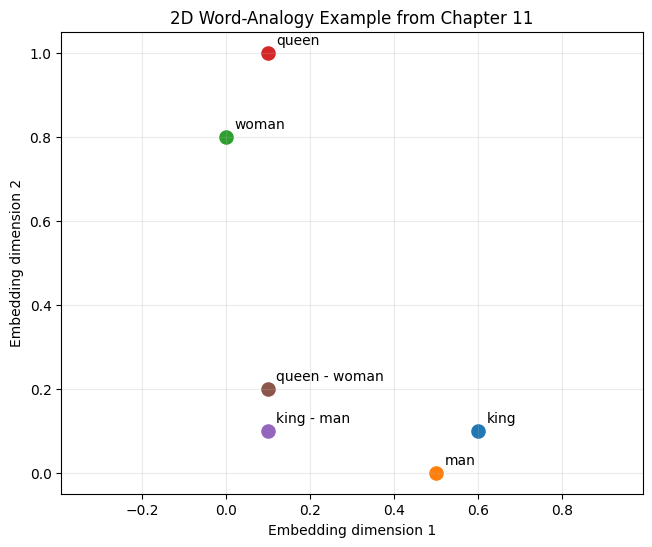

In [18]:
points = {
    "king": king,
    "man": man,
    "woman": woman,
    "queen": queen,
    "king - man": king_minus_man,
    "queen - woman": queen_minus_woman
}

plt.figure(figsize=(7.5, 6))
for label, point in points.items():
    plt.scatter(point[0], point[1], s=90)
    plt.text(point[0] + 0.02, point[1] + 0.02, label)

plt.xlabel("Embedding dimension 1")
plt.ylabel("Embedding dimension 2")
plt.title("2D Word-Analogy Example from Chapter 11")
plt.grid(alpha=0.25)
plt.axis("equal")
plt.show()

### Apa yang ditunjukkan?

Source memberikan:

- `king = [0.6, 0.1]`
- `man = [0.5, 0.0]`
- `woman = [0.0, 0.8]`
- `queen = [0.1, 1.0]`

Sehingga:

- `king − man = [0.1, 0.1]`
- `queen − woman = [0.1, 0.2]`

Perbedaan tersebut menunjukkan arah yang relatif mirip. Buku mengaitkannya dengan informasi yang dipelajari dari co-occurrence dan loss function.

## Source Code: Core Sentiment Embedding

Berikut bagian inti implementasi yang diperkenalkan source untuk embedding sentiment. Dataset `reviews.txt` dan `labels.txt` tidak tersedia di environment notebook ini, sehingga cell berikut digunakan sebagai **source reproduction** dan tidak dijalankan terhadap dataset asli.

In [19]:
import numpy as np

np.random.seed(1)

def sigmoid(x):
    return 1/(1 + np.exp(-x))

alpha, iterations = (0.01, 2)
hidden_size = 100

# Source:
# weights_0_1 = 0.2*np.random.random((len(vocab),hidden_size)) - 0.1
# weights_1_2 = 0.2*np.random.random((hidden_size,1)) - 0.1

def sentiment_forward(input_indices, weights_0_1, weights_1_2):
    layer_1 = sigmoid(np.sum(weights_0_1[input_indices], axis=0))
    layer_2 = sigmoid(np.dot(layer_1, weights_1_2))
    return layer_1, layer_2

print("Sentiment embedding architecture defined.")
print("alpha =", alpha)
print("iterations =", iterations)
print("hidden_size =", hidden_size)

Sentiment embedding architecture defined.
alpha = 0.01
iterations = 2
hidden_size = 100


## Source Code: Fill-in-the-Blank Similarity

Source menggunakan `similar(target)` untuk membandingkan row embedding dengan Euclidean distance. Score disimpan sebagai negatif jarak sehingga kata yang lebih dekat memiliki score yang lebih tinggi (lebih dekat ke `0`).

In [20]:
from collections import Counter
import math

def similar(target, word2index, weights_0_1):
    target_index = word2index[target]
    scores = Counter()

    for word, index in word2index.items():
        raw_difference = weights_0_1[index] - weights_0_1[target_index]
        squared_difference = raw_difference * raw_difference
        scores[word] = -math.sqrt(sum(squared_difference))

    return scores.most_common(10)

print("Function similar() reproduced from the source structure.")

Function similar() reproduced from the source structure.


## Source Code: Word Analogy

Source membentuk `query_vect` dengan:
- menambahkan embedding dari positive words;
- mengurangi embedding dari negative words;
- kemudian mencari word vector yang paling dekat dengan query tersebut.

Contoh source:
`analogy(['terrible','good'], ['bad'])`

menghasilkan kata-kata seperti `superb`, `terrific`, `decent`, dan `fine` sebagai kandidat teratas.

In [21]:
def analogy(positive, negative, word2index, weights_0_1):
    norms = np.sum(weights_0_1 * weights_0_1, axis=1)
    norms.resize(norms.shape[0], 1)

    normed_weights = weights_0_1 * norms

    query_vect = np.zeros(len(weights_0_1[0]))

    for word in positive:
        query_vect += normed_weights[word2index[word]]

    for word in negative:
        query_vect -= normed_weights[word2index[word]]

    scores = Counter()

    for word, index in word2index.items():
        raw_difference = weights_0_1[index] - query_vect
        squared_difference = raw_difference * raw_difference
        scores[word] = -math.sqrt(sum(squared_difference))

    return scores.most_common(10)[1:]

print("Function analogy() reproduced from the source structure.")

Function analogy() reproduced from the source structure.


## Concept Check

| Pertanyaan | Jawaban inti |
|---|---|
| Mengapa text perlu diubah menjadi angka? | Neural network memproses input numerik, bukan raw text secara langsung. |
| Apa itu one-hot encoding? | Representasi vector yang menandai posisi kata dalam vocabulary. |
| Mengapa embedding layer lebih efisien? | Karena langsung memilih row weights yang relevan daripada melakukan banyak operasi dengan nilai `0`. |
| Apa yang menentukan “meaning” sebuah neuron? | Target labels dan correlation yang diperlukan untuk mencapai target tersebut. |
| Mengapa target berbeda menghasilkan embedding berbeda? | Karena loss signal yang harus diminimalkan berbeda. |
| Apa tujuan fill-in-the-blank? | Memberikan learning signal yang lebih kaya mengenai hubungan antar kata dan context. |
| Apa itu negative sampling? | Memilih subset label negatif sehingga tidak perlu memprediksi seluruh vocabulary setiap forward propagation. |
| Apa ide `king − man + woman ≈ queen`? | Relasi antar word vectors dapat menunjukkan pola analogi yang muncul dari informasi co-occurrence dan objective yang digunakan. |

## Key Takeaways

1. **NLP** menggunakan neural network untuk memodelkan berbagai pola pada language.
2. Raw text harus dikonversi menjadi **numerical representation**.
3. **One-hot / bag-of-words** dapat menjadi representasi awal, tetapi sangat sparse.
4. `weights_0_1` dapat digunakan sebagai **embedding layer** melalui row selection dan summation.
5. Word similarity dapat dihitung dengan **Euclidean distance**.
6. Embedding tidak memiliki “meaning” universal; representasinya bergantung pada **target prediction**.
7. **Loss function** menentukan pola apa yang diberi signal untuk dipelajari.
8. Fill-in-the-blank memberikan signal yang lebih nuanced daripada binary sentiment.
9. Word embeddings dapat menghasilkan fenomena **word analogies**.
10. Chapter 11 menjadi fondasi penting sebelum masuk ke **variable-length sequences dan recurrent layers** pada Chapter 12.

## Chapter Summary

Chapter 11 memperkenalkan penggunaan neural networks untuk **language**. Dimulai dari supervised NLP dan IMDB movie reviews, text dikonversi menjadi numerical representation menggunakan one-hot encoding dan bag-of-words.

Selanjutnya, chapter memperkenalkan **embedding layer** sebagai cara yang lebih efisien untuk memperoleh representasi hidden dari kumpulan kata. Hasil training kemudian digunakan untuk melihat kata-kata yang memiliki representasi serupa.

Insight terpenting chapter adalah bahwa representasi kata sangat bergantung pada **apa yang network diminta untuk prediksi**. Sentiment prediction membuat kata dikelompokkan berdasarkan usefulness terhadap positive/negative labels, sedangkan fill-in-the-blank menghasilkan signal yang lebih kaya mengenai hubungan antar kata.

Chapter ditutup dengan **word analogies**, termasuk contoh `king − man + woman ≈ queen`, sebagai konsekuensi menarik dari struktur yang dipelajari dalam word embeddings.

## Reference

Trask, A. W. (2019). *Grokking Deep Learning*. Manning Publications.

Notebook ini mengikuti struktur, terminology, code patterns, dan output yang tersedia pada Chapter 11. Visual tambahan yang diberi label **illustrative**, **conceptual**, atau **structural** dibuat untuk membantu memahami source dan tidak diklaim sebagai hasil eksperimen tambahan dari buku.